In [2]:
import google.auth
import numpy as np
import pandas as pd
import geopandas as gpd
from calitp_data_analysis import geography_utils
from calitp_data_analysis.sql import to_snakecase
from shared_utils import arcgis_query

In [3]:

import re
import pyarrow.parquet as pq
import gcsfs

In [4]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

In [5]:
from calitp_data_analysis import get_fs
fs = get_fs()

In [6]:

import os
from typing import List, Optional, Union
import pyarrow.dataset as ds
from google.cloud import storage

In [7]:
import google.auth
import pandas_gbq

credentials, project = google.auth.default()
from functools import cache

from calitp_data_analysis.gcs_pandas import GCSPandas
from calitp_data_analysis.gcs_geopandas import GCSGeoPandas
from calitp_data_analysis.sql import to_snakecase

In [8]:
from typing import List

In [9]:
import geopandas as gpd
import pandas as pd

In [10]:
from functools import cache

from calitp_data_analysis.gcs_geopandas import GCSGeoPandas

@cache
def gcs_geopandas():
    return GCSGeoPandas()

In [11]:
@cache
def gcs_pandas():
    return GCSPandas()

In [12]:
gcsgp = GCSGeoPandas()

# Census Blocks

In [13]:
census_block_url = "gs://calitp-analytics-data/data-analyses/equity_index/unbuffered_censusblocks_2020/combined_unbufferd_ca_2020.parquet"

In [14]:
census_df = to_snakecase(gcsgp.read_parquet(
   census_block_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [15]:
geography_utils.CA_NAD83Albers_m

'EPSG:3310'

In [16]:
census_df.shape

(519723, 19)

In [17]:
test_blocks = ['060750204024001', '060750260031011', '060750230032004']

In [18]:
sf_only = census_df.loc[census_df.geoid20.isin(test_blocks)]

In [19]:
sf_only.shape

(3, 19)

## HPMS

In [20]:


hpms_url = "gs://calitp-analytics-data/data-analyses/equity_index/HPMS21_Main_SUCU.parquet"



In [21]:
hpm_df = to_snakecase(gcsgp.read_parquet(
    hpms_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [22]:
# Filter to f_system 1,2 temporarily
# hpm_df2 = hpm_df.loc[hpm_df.f_system.isin([1,2])]

In [23]:
buffer_list = [500, 450, 400, 350, 300, 250, 200, 150, 100, 50]

In [24]:
#for buffer in [150,100]:
  # df = buffer_hpm(gdf=hpm_df, buffer = buffer)

In [25]:
"""

dims = set(
    len(pt)
    for geom in hpm_df.geometry
    for line in geom.geoms            # iterate through each LineString
    for pt in line.coords             # now safe to access coords
)

"""

'\n\ndims = set(\n    len(pt)\n    for geom in hpm_df.geometry\n    for line in geom.geoms            # iterate through each LineString\n    for pt in line.coords             # now safe to access coords\n)\n\n'

In [26]:
# hpm_gdf = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_500_hpm.parquet")

In [27]:
# intersect = gpd.overlay(hpm_gdf, sf_only, how = "intersection",keep_geom_type= False)

## Main function

In [138]:
def intersect_hpm_census(hpm_gdf:gpd.GeoDataFrame, census_gdf:gpd.GeoDataFrame, buffer: int, file_name:str)->pd.DataFrame:
    #hpm_gdf.geometry = hpm_gdf.geometry.buffer(buffer)

    # Read in Buffer
    hpm_gdf = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_{buffer}_hpm.parquet")
    
    intersect = gpd.overlay(hpm_gdf, census_gdf, how = "intersection",keep_geom_type= False)

    # Create an unique ID 
    intersect["unique_id"] = intersect.routeid + "_" + intersect.geoid20

    # Combine the geometries for each unique_id and find the max AADT
    dissolved = intersect.dissolve(
    by=["geoid20", "unique_id",],
    aggfunc={
        "aadt": "max",     # Get the max for each unique_id
    }).reset_index()

    # Find the area for each unique_id
    dissolved["area"] = dissolved.geometry.area

    # Need to find the sum of the area for a censusblock
    agg = dissolved.groupby("geoid20").agg({"aadt":"max", "area":"sum"}).reset_index()

    # Calculate the score
    agg[f"aadt_{buffer}_score":"sum"] = agg.aadt * agg.area
    
    # Save to GCS
    agg.to_parquet("./agg2.parquet")
    fs.put("./agg2.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/{file_name}_traffic_proximity_overlay_{buffer}.parquet")
    print(f"finshed saving data for {buffer}")
    
    return agg

In [101]:
hpm_gdf = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/hpm/buffer_500_hpm.parquet")
intersect = gpd.overlay(hpm_gdf, sf_only, how = "intersection",keep_geom_type= False)

In [102]:
intersect["unique_id"] = intersect.routeid + "_" + intersect.geoid20

In [103]:
intersect.unique_id.value_counts().head()

unique_id
SF_SF_SILVER AVE_P_060750230032004      5
SF_SF_REVERE AVE_P_060750230032004      4
SF_SF_WILLIAMS AVE_P_060750230032004    3
SF_SF_21ST ST_P_060750204024001         3
SF_SF_MENDELL ST_P_060750230032004      3
Name: count, dtype: int64

In [123]:

dissolved = intersect.dissolve(
    by=["geoid20", "unique_id",],
    aggfunc={
        "aadt": "max",     # important: matches fmax(AADT)
        # for all other numeric fields, choose "first" or drop them
    }
).reset_index()


In [99]:
dissolved.shape

(123, 3)

In [100]:
intersect.unique_id.nunique(), len(dissolved)

(123, 123)

In [125]:
dissolved["area"] = dissolved.geometry.area

In [126]:
dissolved.loc[dissolved.unique_id == "SF_SF_SILVER AVE_P_060750230032004"]

,geoid20,unique_id,geometry,aadt,area
79,060750230032004,SF_SF_SILVER AVE_P_060750230032004,"POLYGON ((-210981.410 -28903.156, -210929.254 -28877.342, -210916.311 -28886.412, -210916.311 -28886.412, -210896.987 -28899.954, -210873.367 -28912.894, -210872.813 -28913.509, -210969.955 -28968.270, -210996.067 -28985.058, -211020.629 -29003.434, -211021.771 -29003.197, -211021.771 -29003.197, -211030.704 -29001.345, -211083.368 -28990.428, -211037.299 -28940.775, -210981.410 -28903.156))",11577,10836.15


In [109]:
dissolved.head(1)

,geoid20,unique_id,geometry,aadt
0,060750204024001,SF_SF_18TH ST_P_060750204024001,"POLYGON ((-214919.231 -26157.096, -214871.373 -26123.745, -214853.800 -26152.221, -214919.264 -26199.353, -214906.490 -26219.365, -214913.479 -26224.189, -214916.784 -26232.889, -214925.563 -26221.765, -214927.467 -26213.709, -214937.784 -26170.074, -214919.231 -26157.096))",15534


In [135]:
dissolved.loc[dissolved.geoid20 == "060750204024001"].area.sum()

125017.52765640143

In [136]:
dissolved2 = dissolved.groupby("geoid20").agg({"aadt":"max", "area":"sum"}).reset_index()

In [137]:
dissolved2.loc[dissolved2.geoid20 == "060750204024001"]

,geoid20,aadt,area
0,060750204024001,15534,125017.53


In [130]:
dissolved2["buffer_500_score"] = dissolved2.aadt * dissolved2.area

In [131]:
dissolved2

,geoid20,aadt,area,buffer_500_score
0,060750204024001,15534,3348.71,52018792.28
1,060750230032004,202000,14006.99,2829411197.24
2,060750260031011,9502,16164.98,153599617.01


In [132]:
52018792.28-170568968.38

-118550176.1

In [119]:
dissolved2

,geoid20,buffer_500_score
0,060750204024001,170568968.38
1,060750230032004,826218383.20
2,060750260031011,466259380.80


In [58]:
buffer_500 = intersect_hpm_census(hpm_gdf=hpm_df, census_gdf=sf_only, buffer = buffer_list[0], file_name = "three_blocks_sf_test_")

done with finding area
done with finding max value
Done aggregating
Done calculating max score
finshed saving data for 500


In [31]:
census_blocks_dfs = []

In [32]:
#     gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_
for size in buffer_list:
    path = f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_{size}.parquet"
    df = gcsgp.read_parquet(path)
    census_blocks_dfs.append(df)

In [37]:
df_50 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_50.parquet")

In [38]:
df_100 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_100.parquet")

In [39]:
df_150 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_150.parquet")

In [40]:
df_200 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_200.parquet")

In [41]:
df_250 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_250.parquet")

In [42]:
df_300 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_300.parquet")

In [43]:
df_350 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_350.parquet")

In [44]:
df_400 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_400.parquet")

In [45]:
df_450 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_450.parquet")

In [46]:
df_500 = gcsgp.read_parquet(f"gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_500.parquet")

In [ ]:

def load_eqi_traffic_parquets(file_name:str):
    """
    Reads all EQI traffic parquet files from the GCS folder
    and concatenates them together on the column 'geoid20'.
    """
    sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
   
    
    dfs = []

    for size in sizes:
        path = f"{file_name}{size}.parquet"
        df = gcs_pandas().read_parquet(path)
        dfs.append(df)

   # Merge all dfs on geoid20
    combined = dfs[0]
    for df in dfs[1:]:
        combined = combined.merge(df, on="geoid20", how="outer")


    # Optional: ensure geoid20 exists
    if "geoid20" not in combined.columns:
        raise ValueError("Column 'geoid20' not found in concatenated data.")

    return combined


In [ ]:

df = gcs_pandas().read_parquet("gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_400.parquet")

In [ ]:
# gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_test_traffic_proximity_overlay_500.parquet
df = load_eqi_traffic_parquets(file_name = "gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sf_3_census_blocks_traffic_proximity_overlay_")

In [ ]:
df.shape, sf_only.shape

In [ ]:
df.to_csv("sf_only_traffic_proximity.csv")

In [ ]:
df["p_50_m"]  = df["aadt_50_score"]

In [ ]:
df["p_100_m"] = df["aadt_100_score"] - df["aadt_50_score"]

In [ ]:
df["p_150_m"] = df["aadt_150_score"] - df["aadt_100_score"]

In [ ]:
df["p_200_m"] = df["aadt_200_score"] - df["aadt_150_score"]

In [ ]:
df["p_250_m"] = df["aadt_250_score"] - df["aadt_200_score"]

In [ ]:
df["p_300_m"] = df["aadt_300_score"] - df["aadt_250_score"]

In [ ]:
df["p_350_m"] = df["aadt_350_score"] - df["aadt_250_score"]

In [ ]:
df["p_400_m"] = df["aadt_400_score"] - df["aadt_350_score"]

In [ ]:
df["p_450_m"] = df["aadt_450_score"] - df["aadt_400_score"]

In [ ]:
df["p_500_m"] = df["aadt_500_score"] - df["aadt_450_score"]

In [ ]:
weights = {
	        "p_50_m": 1.0,
	        "p_100_m": 0.5,
	        "p_150_m": 0.33,
	        "p_200_m": 0.25,
	        "p_250_m": 0.20,
	        "p_300_m": 0.16,
	        "p_350_m": 0.14,
	        "p_400_m": 0.125,
	        "p_450_m": 0.111,
	        "p_500_m": 0.10,
    }

In [ ]:
weights = {
	        "p_50_m": 1.0,
	        "p_100_m": 0.5,
	        "p_150_m": 0.33,
    }

In [ ]:
for col, w in weights.items():
    df[f"{col}_w"] = df[col] * w

In [ ]:
weighted_cols = [f"{col}_w" for col in weights.keys()]
df["weighted_aadt_score"] = df[weighted_cols].sum(axis=1)

In [ ]:
df.head(2)

In [ ]:
df2 = df[["geoid20", "weighted_aadt_score"]].copy().fillna(0)

In [ ]:
df2["traffic_proximity_and_volume_percentile"] = (
	        df2["weighted_aadt_score"].rank(pct=True)
    )

In [ ]:
df2.head()

In [ ]:
df2.weighted_aadt_score.describe()

In [ ]:
df2.traffic_proximity_and_volume_percentile.describe()

In [ ]:
sf_only.loc[sf_only.pop20 != 0].shape

In [ ]:
m1 = pd.merge(sf_only[["geoid20","county_name", "geometry"]], df2, on = ["geoid20"], how = "left")

In [ ]:
m1.shape

In [ ]:
m1.columns

In [ ]:
m1.county_name.unique()

In [ ]:
m1.loc[(m1.county_name == "San Francisco")&(m1.traffic_proximity_and_volume_percentile > 0.9)].shape

In [ ]:
m1.loc[(m1.county_name == "San Francisco")][["traffic_proximity_and_volume_percentile"]].describe()

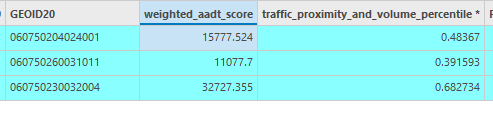

In [ ]:
m1.drop(columns = ["geometry"]).head(3)

In [ ]:
m1.explore("traffic_proximity_and_volume_percentile")